In [1]:
import os
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, wasserstein_distance, chisquare, norm
import matplotlib.pyplot as plt
from collections import deque
import numpy as np
import requests as req
from numpy.random import PCG64, Generator
from ast import literal_eval

In [2]:
PLOT_MAP = [
    #Gen ROW COLUMN
    ("pcg64".upper(), 0, 0),
    ("mt19937".upper(),0, 1),
    ("philox".upper(),1, 0),
    ("sfc64".upper(), 1, 1),
    ("TRNG".upper(), 2, 0)
]
generators = ["pcg64", "mt19937", "philox", "sfc64"]

In [3]:
PROJECT_ROOT_DIR = "./."
BASE_IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", "summary")
os.makedirs(BASE_IMAGES_PATH, exist_ok = True)

def save_figure(fig_id, image_path, tight_layout = True, fig_extension = "png", resolution = 300):
    path = os.path.join(image_path, fig_id + "." + fig_extension)
    print(f"Saving figure {fig_id}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format = fig_extension, dpi = resolution)

In [4]:
class Qrng:
    def __init__(self, domain) -> None:
        self.__domain = domain
        self.__api_int = "https://{}/api/2.0/int".format(self.__domain)
        self.__api_bytes ="https://{}/api/2.0/streambytes".format(self.__domain)

    def qrand_int(self, low, hi, samples) -> list[int]:
        session = req.Session()
        payload = {"min": low, "max": hi, "quantity": samples}
        response = session.get(self.__api_int, params = payload)
        res = literal_eval(response.text)
        return res

    def qrand_bytes(self, size) -> bytes:
        session = req.Session()
        payload = {"size": size}
        response = session.get(self.__api_bytes, params = payload)
        
        return response.content

def qrandbytes(size=1024) -> bytes:
    qrng = Qrng("random.cs.upt.ro")
    values = qrng.qrand_bytes(size)
    return values
    
def qrandint(l, h, n, pool_size = 100000) -> np.array:
    if not hasattr(qrandint, "ivalues"):
       qrandint.ivalues = {}

    key = str(l) + str(h)
    if key in qrandint.ivalues:
        # found the key
        values = qrandint.ivalues[key]
        if len(values) == 0 or len(values) < n:
            qrng = Qrng("random.cs.upt.ro")
            values = qrng.qrand_int(l, h, (n + pool_size))
            qrandint.ivalues[key] += values
        else:
            pass
    else:
        qrng = Qrng("random.cs.upt.ro")
        qrandint.ivalues[key] = qrng.qrand_int(l, h, (n + pool_size))

    outvals = qrandint.ivalues[key][:n]
    del qrandint.ivalues[key][:n]
    return np.array(outvals, dtype = np.uint32)

In [5]:
def randint(l, h, n, generator="pcg64", seed=None, dtype = np.uint32):
    generators = {
        "pcg64": np.random.PCG64,
        "mt19937": np.random.MT19937,
        "philox": np.random.Philox,
        "sfc64": np.random.SFC64,
    }
    if generator not in generators:
        raise ValueError(f"Unknown generator: {generator}. Choose from {list(generators.keys())}")
    rng = np.random.default_rng(generators[generator](seed))
    return rng.integers(l, h, size=n, dtype=dtype)

In [6]:
RANGE_MIN = 0
RANGE_MAX = 1000
ARRAY_SIZE = 10000

In [7]:
data = [
    *[(gen_i.upper(), randint(RANGE_MIN, RANGE_MAX + 1, ARRAY_SIZE, generator=gen_i)) for gen_i in generators],
    ("TRNG",qrandint(RANGE_MIN, RANGE_MAX + 1, ARRAY_SIZE, pool_size = 100000))
    
]

In [8]:
data

[('PCG64',
  array([407, 931,  13, ..., 163, 964, 911], shape=(10000,), dtype=uint32)),
 ('MT19937',
  array([478, 515, 804, ..., 400, 483,  10], shape=(10000,), dtype=uint32)),
 ('PHILOX',
  array([468, 958, 864, ..., 642, 949, 356], shape=(10000,), dtype=uint32)),
 ('SFC64',
  array([571, 523, 586, ..., 834, 231, 944], shape=(10000,), dtype=uint32)),
 ('TRNG',
  array([917, 646, 534, ..., 377, 404, 774], shape=(10000,), dtype=uint32))]

# Analyzing data

Saving figure uniformity


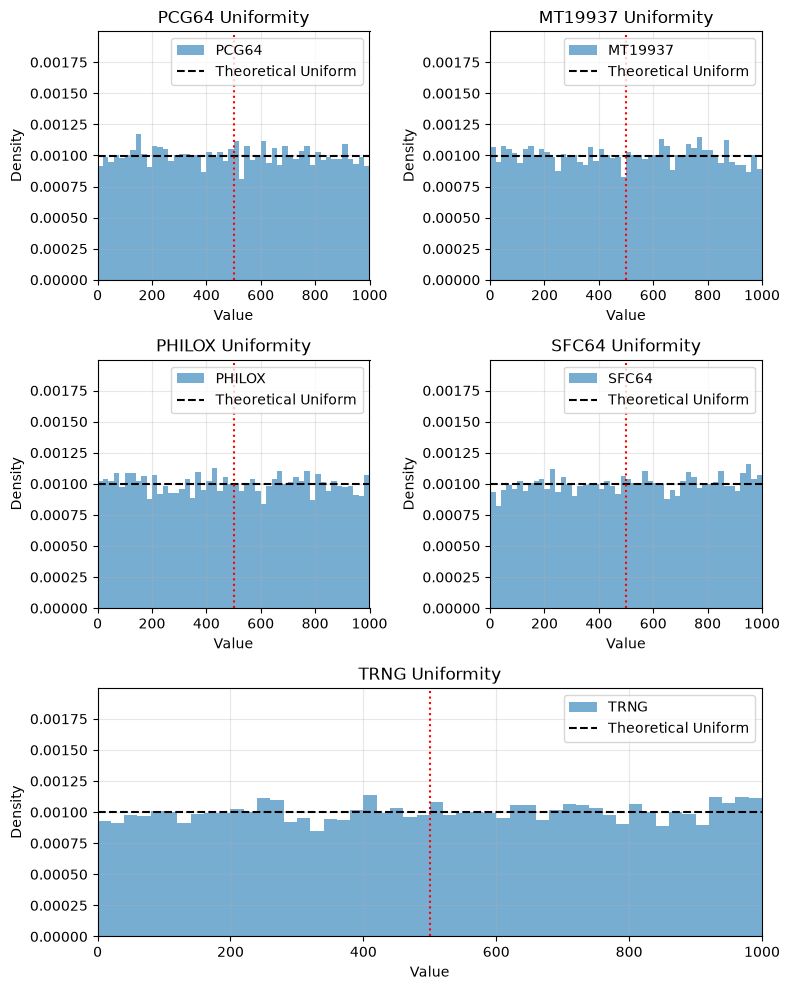

In [9]:
bins = 50
k = RANGE_MAX - RANGE_MIN + 1

####
fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []

mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2
for (generator, row, column) in PLOT_MAP:
    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])
    value = next(item[1] for item in data if item[0] == generator)
    ax.hist(value, bins=bins, alpha=0.6, density=True, label=generator)
    ax.hlines(
        y=1/k,
        xmin=RANGE_MIN,
        xmax=RANGE_MAX,
        colors="black",
        linestyles="dashed",
        label="Theoretical Uniform"
    )
    ax.set_title(f"{generator} Uniformity")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    axes.append(ax)


for i, ax in enumerate(axes):
    ax.set_xlim(RANGE_MIN, RANGE_MAX)
    ax.set_ylim(0, 2/k)
    ax.grid(alpha=0.3)
    ax.axvline(mean_theoretical, color="red", linestyle=":", label="Mean")


plt.tight_layout()
save_figure("uniformity", BASE_IMAGES_PATH)
plt.show()








Saving figure spread_comparison_boxplot


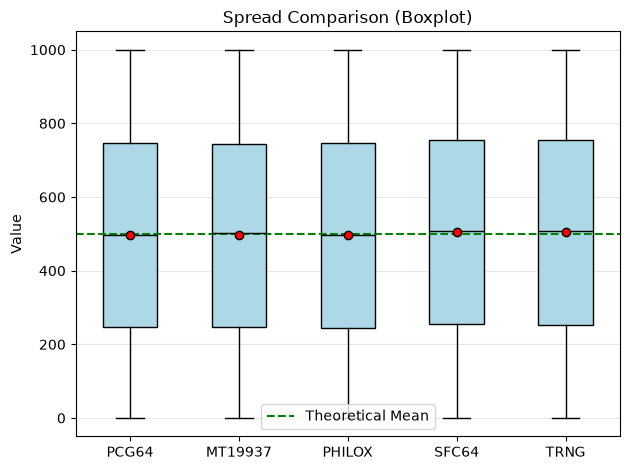

In [10]:
plt.figure()
mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2

labels, arrays = map(list, zip(*data))

plt.boxplot(
    arrays,
    tick_labels=labels,
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="black"),
    meanprops=dict(marker="o", markerfacecolor="red", markeredgecolor="black")
)

plt.axhline(
    mean_theoretical,
    color="green",
    linestyle="--",
    label="Theoretical Mean"
)

plt.title("Spread Comparison (Boxplot)")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)
plt.legend()
save_figure("spread_comparison_boxplot", BASE_IMAGES_PATH)
plt.show()

Saving figure deviation_from_uniform_distribution


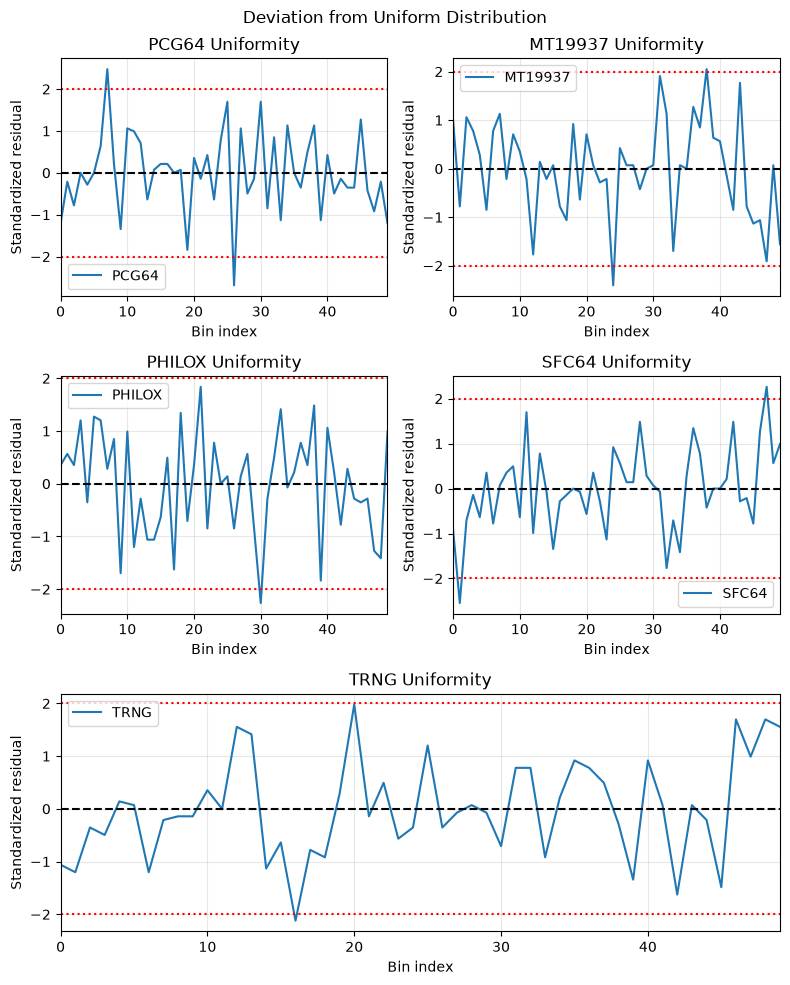

In [24]:
bins = 50
expected_prob = 1 / bins   # IMPORTANT: matches histogram bins!

fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []

mean_theoretical = (RANGE_MIN + RANGE_MAX) / 2
for generator, row, column in PLOT_MAP:

    value = next(item[1] for item in data if item[0] == generator)

    value_hist, _ = np.histogram(
        value,
        bins=bins,
        range=(RANGE_MIN, RANGE_MAX)
    )

    expected_count = len(value) / bins

    residual = (
        value_hist - expected_count
    ) / np.sqrt(expected_count)

    x = np.arange(bins)

    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])

    ax.plot(x, residual, label=generator)

    ax.axhline(0, linestyle="--", color="black")
    ax.axhline(2, linestyle=":", color="red")
    ax.axhline(-2, linestyle=":", color="red")

    ax.set_xlim(0, bins - 1)
    ax.set_ylabel("Standardized residual")
    ax.set_xlabel("Bin index")
    ax.set_title(f"{generator} Uniformity")
    ax.grid(alpha=0.3)
    ax.legend()

    axes.append(ax)

fig.suptitle("Deviation from Uniform Distribution")

fig.tight_layout()

save_figure(
    "deviation_from_uniform_distribution",
    BASE_IMAGES_PATH
)

plt.show()


In [14]:
from statsmodels.distributions.empirical_distribution import ECDF

Saving figure cdf_deviation


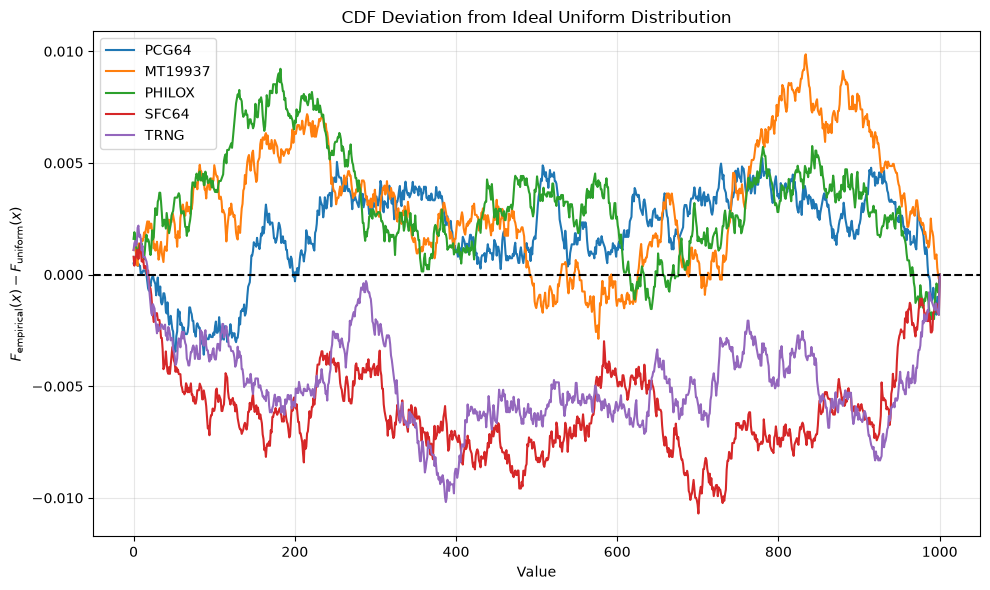

In [16]:
plt.figure(figsize=(10, 6))

x = np.linspace(RANGE_MIN, RANGE_MAX, 1000)

ideal_cdf = (x - RANGE_MIN) / (RANGE_MAX - RANGE_MIN)

for generator, array in data:
    value_ecdf = ECDF(array)

    deviation = value_ecdf(x) - ideal_cdf

    plt.plot(
        x,
        deviation,
        label=generator
    )

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Value")
plt.ylabel(r"$F_{\mathrm{empirical}}(x) - F_{\mathrm{uniform}}(x)$")
plt.title("CDF Deviation from Ideal Uniform Distribution")

plt.legend()
plt.grid(alpha=0.3)

save_figure("cdf_deviation", BASE_IMAGES_PATH)
plt.show()

# Statistical moments

In [18]:
theoretical_mean = (RANGE_MAX - 1) / 2
print(f"Theoretical Mean:{theoretical_mean}")
for generator, array in data:
    array_mean = np.mean(array)
    array_error = array_mean - theoretical_mean

    array_relative_error = abs(array_error)/theoretical_mean
    print(f"{generator}:\n\tMean:{array_mean}\n\tError:{array_error}\n\tRelative Error:{array_relative_error}\n================")

Theoretical Mean:499.5
PCG64:
	Mean:498.0659
	Error:-1.4341000000000008
	Relative Error:0.002871071071071073
MT19937:
	Mean:496.8534
	Error:-2.646599999999978
	Relative Error:0.005298498498498455
PHILOX:
	Mean:496.8366
	Error:-2.663400000000024
	Relative Error:0.005332132132132181
SFC64:
	Mean:506.0625
	Error:6.5625
	Relative Error:0.013138138138138139
TRNG:
	Mean:504.8288
	Error:5.328800000000001
	Relative Error:0.01066826826826827


In [20]:
theoretical_std = np.sqrt((RANGE_MAX ** 2 - 1) / 12)
print(f"Theoretical STD:{theoretical_std}")

for generator, arr in data:
    arr_std = np.std(arr)
    arr_error = arr_std - theoretical_std
    arr_relative_error = abs(arr_error)/theoretical_std
    print(f"{generator.upper()}:\n\tStd:{arr_std}\n\tError:{arr_error}\n\tRelative Error:{arr_relative_error}\n================")
                          


Theoretical STD:288.6749902572095
PCG64:
	Std:287.33587098931804
	Error:-1.3391192678914763
	Relative Error:0.004638847538189299
MT19937:
	Std:288.0065501137778
	Error:-0.6684401434317238
	Relative Error:0.002315545738257905
PHILOX:
	Std:289.25017355299894
	Error:0.5751832957894294
	Relative Error:0.001992494380191858
SFC64:
	Std:288.66813124027044
	Error:-0.006859016939074536
	Relative Error:2.3760343537080056e-05
TRNG:
	Std:288.81198605764274
	Error:0.13699580043322612
	Relative Error:0.0004745676108316928


In [21]:
theoretical_skew = 0
print(f"Theoretical Skew: {theoretical_skew}\n")
for generator, arr in data:
    arr_skew = skew(arr)
    print(f"{generator} Skew {arr_skew}\n================")

PCG64 Skew 0.007392108495486157
MT19937 Skew -0.009784965092873002
PHILOX Skew -0.0009901234961271917
SFC64 Skew -0.011832098223892624
TRNG Skew -0.008941427927809158


In [23]:
theoretical_kurt = -1.2

theoretical_skew = 0
print(f"Theoretical kurtosis: {theoretical_skew}\n")
for generator, arr in data:
    arr_kurt = kurtosis(arr, fisher=True)
    print(f"{generator} Kurtosis {arr_kurt}\n================")



Theoretical kurtosis: 0

PCG64 Kurtosis -1.2018416281711268
MT19937 Kurtosis -1.2058597271824139
PHILOX Kurtosis -1.2036901236019295
SFC64 Kurtosis -1.2024600900803952
TRNG Kurtosis -1.1954338925963262


=== Pearson Chi-Square Test ===

PCG64:
	Chi2 statistic: 44.51
	p-value: 0.6555204062526457
=== Pearson Chi-Square Test ===

MT19937:
	Chi2 statistic: 47.7
	p-value: 0.5258897708190116
=== Pearson Chi-Square Test ===

PHILOX:
	Chi2 statistic: 46.419999999999995
	p-value: 0.5783334711719282
=== Pearson Chi-Square Test ===

SFC64:
	Chi2 statistic: 40.76
	p-value: 0.7926967220879636
=== Pearson Chi-Square Test ===

TRNG:
	Chi2 statistic: 44.06000000000001
	p-value: 0.6732322829407921
Saving figure chi_square


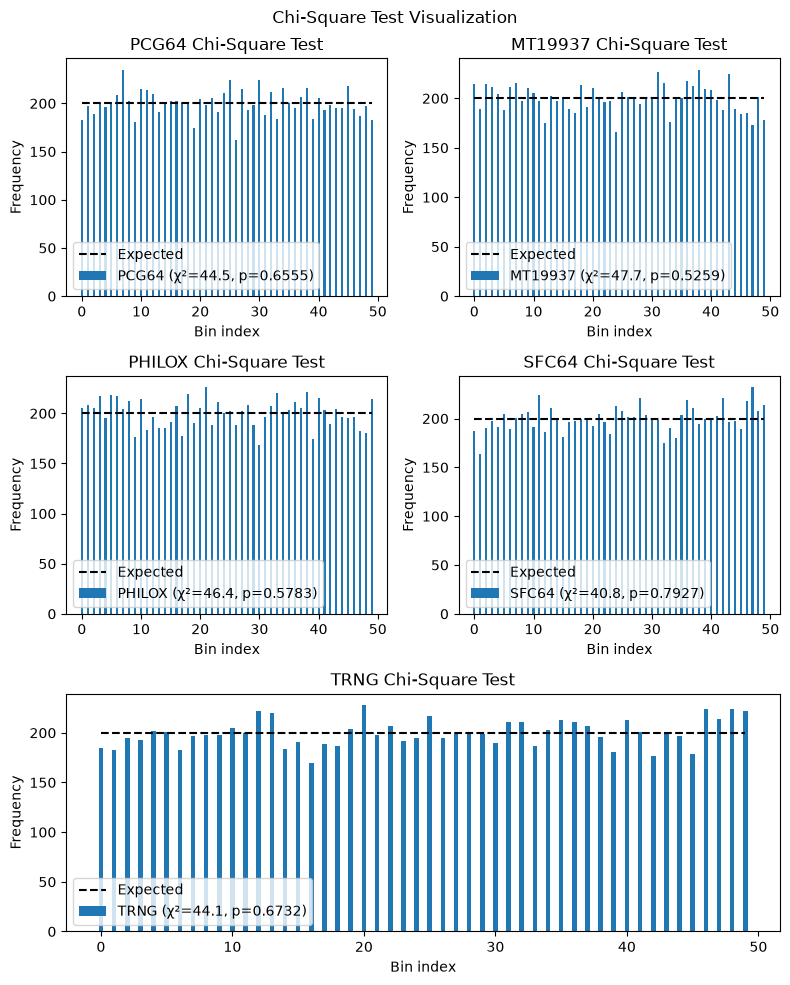

In [29]:
# --- Pearson Chi-Squared Test ---

bins = 50

fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []


x = np.arange(bins)
width = 0.35


for generator, row, column in PLOT_MAP:

    value = next(item[1] for item in data if item[0] == generator)

    value_hist, _ = np.histogram(value, bins=bins, range=(RANGE_MIN, RANGE_MAX))

    # Expected frequencies (uniform)
    expected = np.ones(bins) * (len(value) / bins)
    
    # Run test
    chi_g = chisquare(value_hist, expected)
    
    
    print("=== Pearson Chi-Square Test ===\n")
    
    print(f"{generator}:")
    print(f"\tChi2 statistic: {chi_g.statistic}")
    print(f"\tp-value: {chi_g.pvalue}\n=================")
    
    x = np.arange(bins)
    width = 0.35

    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])

    ax.bar(x, value_hist, width,
        label=f"{generator} (χ²={chi_g.statistic:.1f}, p={chi_g.pvalue:.4f})")
    ax.plot(x, expected, 'k--', label="Expected")

    ax.set_xlabel("Bin index")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{generator} Chi-Square Test")
    ax.legend()

    
    axes.append(ax)

fig.suptitle("Chi-Square Test Visualization")

fig.tight_layout()

save_figure(
    "chi_square",
    BASE_IMAGES_PATH
)

plt.show()

=== Wasserstein Distance ===

PCG64: 2.6045886288628606
MT19937: 3.3777687168716666
PHILOX: 3.249278167816761
SFC64: 6.071997449745002
TRNG: 4.855225342534279
Saving figure wasserstein


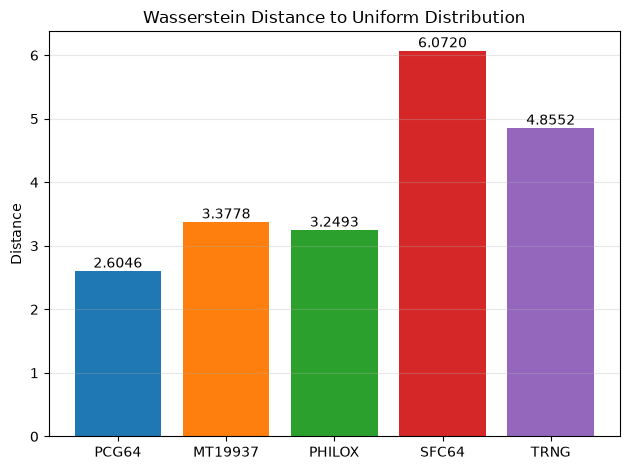

In [31]:

uniform_ref = np.linspace(RANGE_MIN, RANGE_MAX, ARRAY_SIZE)

labels, arrays = map(list, zip(*data))

w_distances = [
    wasserstein_distance(array, uniform_ref)
    for array in arrays
]


print("=== Wasserstein Distance ===\n")
for label, value in zip(labels,w_distances):
    print(f"{label}: {value}")


plt.figure()



plt.bar(labels, w_distances,color=plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(labels)])

plt.title("Wasserstein Distance to Uniform Distribution")
plt.ylabel("Distance")

plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(w_distances):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

save_figure("wasserstein", BASE_IMAGES_PATH)
plt.show()

# MFDFA

In [34]:
from MFDFA import MFDFA
from scipy.stats import linregress

def extract_hq(lag, dfa):
    log_lag = np.log(lag)
    return np.array([linregress(log_lag, np.log(dfa[:, i])).slope for i in range(dfa.shape[1])])

In [ ]:






hq_trng = extract_hq(lag_t, dfa_t)
hq_prng = extract_hq(lag_p, dfa_p)

q_selected = [-10, -5, -2, 2, 5, 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, lag, dfa) in zip(axes, [("TRNG", lag_t, dfa_t), (PRNG.upper(), lag_p, dfa_p)]):
    for q in q_selected:
        idx = np.where(q_list == q)[0][0]
        ax.loglog(lag, dfa[:, idx], label=f"q = {q}")
    idx_ref = np.where(q_list == q_selected[0])[0][0]
    ref_y = dfa[0, idx_ref] * (lag / lag[0]) ** 0.5
    ax.loglog(lag, ref_y, "k--", lw=1.5, label="h = 0.5 (white noise)")
    ax.set_xlabel("s")
    ax.set_ylabel(r"$F_q(s)$")
    ax.set_title(f"{name} — MFDFA")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":")
plt.tight_layout()
save_figure("mfdfa", BASE_IMAGES_PATH)

Saving figure mfdfa


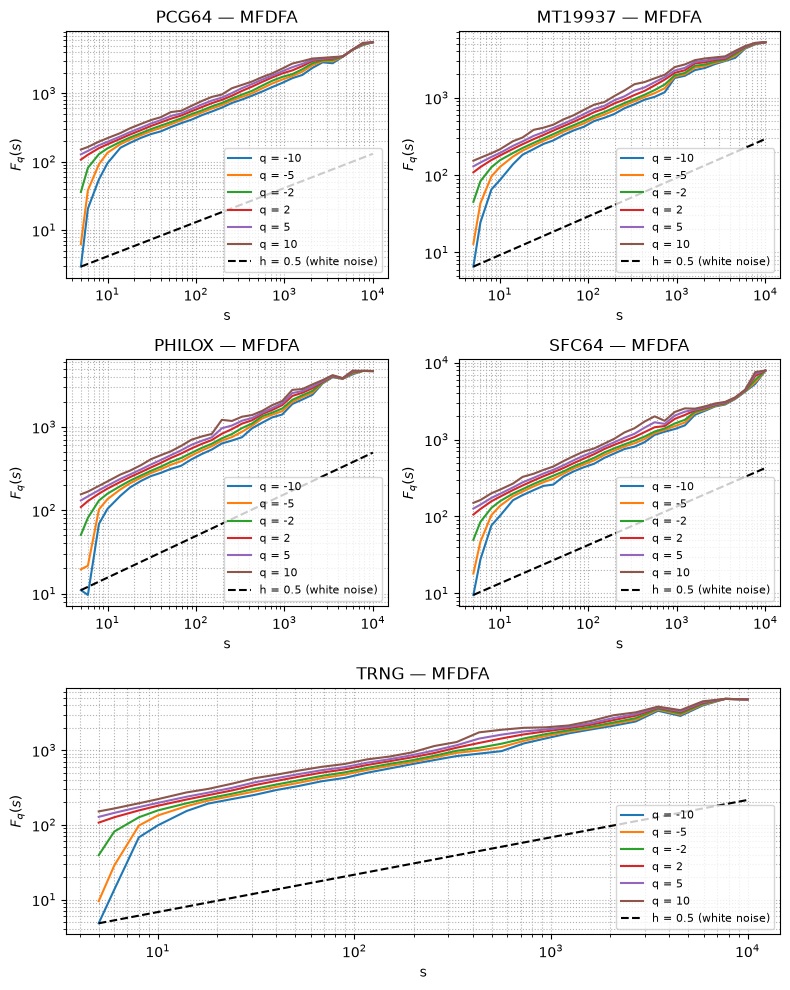

In [35]:
lag = np.logspace(0.7, 4, 30).astype(int)
q_list = np.linspace(-10, 10, 41)
q_list = q_list[q_list != 0.0]
order = 2
q_selected = [-10, -5, -2, 2, 5, 10]
####
fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []


for (generator, row, column) in PLOT_MAP:
    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])
        
    value = next(item[1] for item in data if item[0] == generator)
    
    lag_t, dfa_t = MFDFA(value, lag=lag, q=q_list, order=order)

    for q in q_selected:
        idx = np.where(q_list == q)[0][0]
        ax.loglog(lag_t, dfa_t[:, idx], label=f"q = {q}")
    idx_ref = np.where(q_list == q_selected[0])[0][0]
    ref_y = dfa_t[0, idx_ref] * (lag_t / lag_t[0]) ** 0.5
    ax.loglog(lag_t, ref_y, "k--", lw=1.5, label="h = 0.5 (white noise)")
    ax.set_xlabel("s")
    ax.set_ylabel(r"$F_q(s)$")
    ax.set_title(f"{generator} — MFDFA")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":")

    axes.append(ax)



plt.tight_layout()
save_figure("mfdfa", BASE_IMAGES_PATH)
plt.show()








Saving figure generalized_hurst_exponent
PCG64 h(q) range: [0.480, 0.677]
MT19937 h(q) range: [0.481, 0.658]
PHILOX h(q) range: [0.477, 0.666]
SFC64 h(q) range: [0.486, 0.642]
TRNG h(q) range: [0.467, 0.657]
White noise reference: h(q) = 0.5 for all q


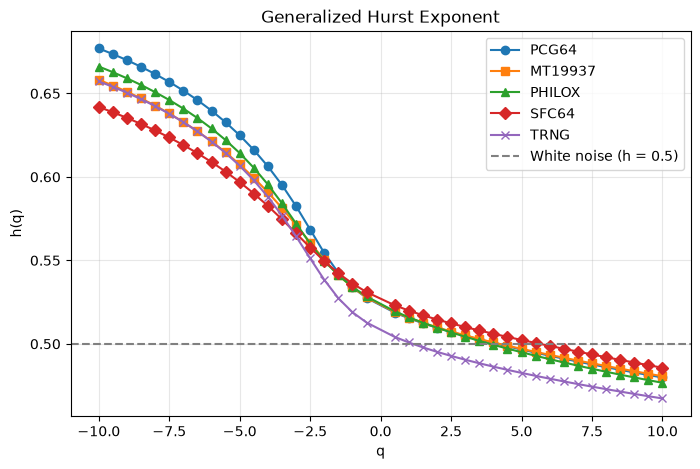

<Figure size 640x480 with 0 Axes>

In [42]:
lag = np.logspace(0.7, 4, 30).astype(int)
q_list = np.linspace(-10, 10, 41)
q_list = q_list[q_list != 0.0]
order = 2
q_selected = [-10, -5, -2, 2, 5, 10]
####

markers = ["o", "s", "^", "D", "x"]

labels, arrays = map(list, zip(*data))

mfdfas = [
    MFDFA(array, lag=lag, q=q_list, order=order) for array in arrays
]

hqs = [extract_hq(lag_t, dfa_t) for (lag_t,dfa_t) in mfdfas]

fig, ax = plt.subplots(figsize=(8, 5))


    
plt.figure()
for (label, value), marker in zip(zip(labels, hqs), markers):
    ax.plot(q_list, value, marker=marker,
        linestyle="-",label=f"{label}")

ax.axhline(0.5, color="gray", ls="--", lw=1.5, label="White noise (h = 0.5)")
ax.set_xlabel("q")
ax.set_ylabel("h(q)")
ax.set_title("Generalized Hurst Exponent")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure("generalized_hurst_exponent", BASE_IMAGES_PATH)


for (label, value) in zip(labels, hqs):
    print(f"{label} h(q) range: [{value.min():.3f}, {value.max():.3f}]")
print(f"White noise reference: h(q) = 0.5 for all q")



# Bit tests, entropy, NIST

In [47]:
BYTE_STREAM_SIZE = 102400

In [48]:
def bytes_to_bits(data: bytes) -> np.ndarray:
    return np.unpackbits(np.frombuffer(data, dtype = np.uint8))


def bit_frequency(data: bytes) -> dict:
    bits = bytes_to_bits(data)
    counts = np.bincount(bits)
    return {"0": int(counts[0]), "1": int(counts[1])}

In [49]:
data_bin = [
    *[(gen_i.upper(), randint(0, 256, BYTE_STREAM_SIZE, generator=gen_i, dtype=np.uint8).tobytes()) for gen_i in generators],
    ("TRNG",qrandbytes(BYTE_STREAM_SIZE))
    
]

In [51]:
for (label, value) in data_bin:
    bit_freq = bit_frequency(value)
    bit_stream_len = len(bytes_to_bits(value))
    print(f"{label} bit frequency: {bit_freq}")
    print(f"{label} fraction of 1s: {bit_freq['1']/bit_stream_len}\n=================")


PCG64 bit frequency: {'0': 409501, '1': 409699}
PCG64 fraction of 1s: 0.500120849609375
MT19937 bit frequency: {'0': 409532, '1': 409668}
MT19937 fraction of 1s: 0.5000830078125
PHILOX bit frequency: {'0': 409829, '1': 409371}
PHILOX fraction of 1s: 0.499720458984375
SFC64 bit frequency: {'0': 409677, '1': 409523}
SFC64 fraction of 1s: 0.499906005859375
TRNG bit frequency: {'0': 614, '1': 586}
TRNG fraction of 1s: 0.48833333333333334


PCG64: chi2 = 0.0479, p-value = 0.8268
MT19937: chi2 = 0.0226, p-value = 0.8806
PHILOX: chi2 = 0.2561, p-value = 0.6128
SFC64: chi2 = 0.0290, p-value = 0.8649
TRNG: chi2 = 0.6533, p-value = 0.4189
Saving figure bit_chisquare


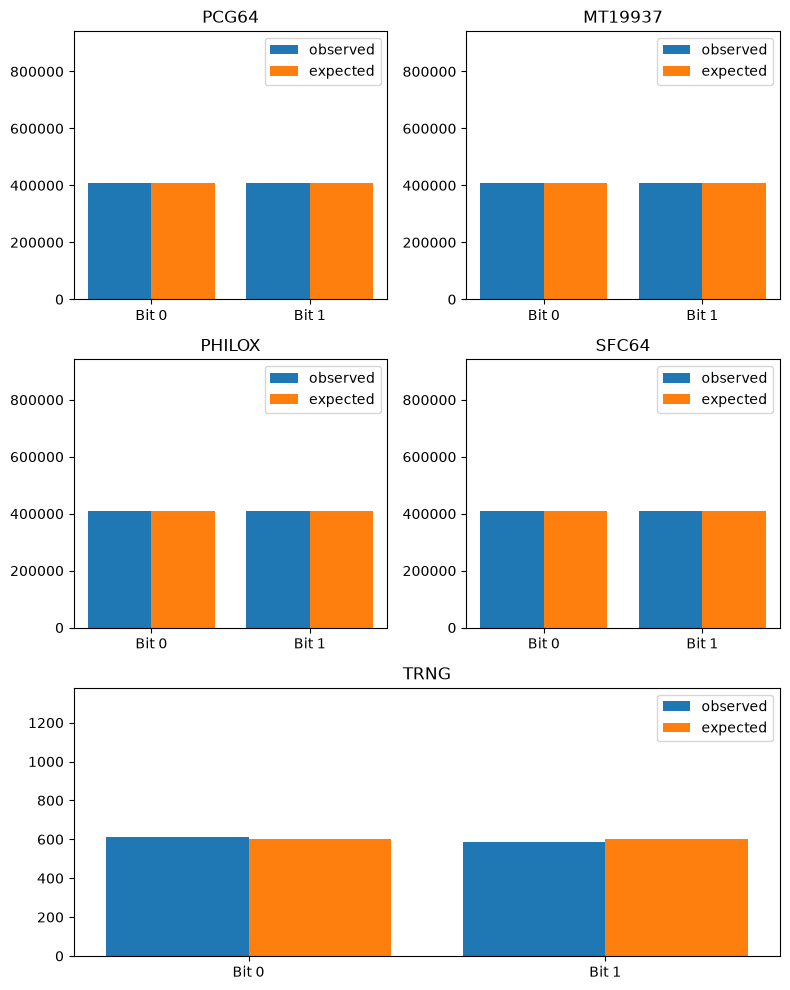

In [54]:
x = np.arange(2)
####
fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 2)
axes = []

for (generator, row, column) in PLOT_MAP:
    if generator == "TRNG":
        ax = fig.add_subplot(gs[row, :])
    else:
        ax = fig.add_subplot(gs[row, column])
    value = next(item[1] for item in data_bin if item[0] == generator)
   
    bit_freq = bit_frequency(value)
    bit_stream_len = len(bytes_to_bits(value))


    observed = [bit_freq["0"], bit_freq["1"]]
    expected = [bit_stream_len / 2, bit_stream_len / 2]
    chi2_stat, p_value = chisquare(observed, expected)
    print(f"{generator}: chi2 = {chi2_stat:.4f}, p-value = {p_value:.4f}")
    
    ax.bar(x - 0.2, observed, 0.4, label = "observed")
    ax.bar(x + 0.2, expected, 0.4, label = "expected")
    ax.set_xticks(x)
    ax.set_xticklabels(["Bit 0", "Bit 1"])
    ax.set_ylim(0, bit_stream_len * 1.15)
    ax.set_title(generator)
    ax.legend() 

    axes.append(ax)


plt.tight_layout()
save_figure("bit_chisquare", BASE_IMAGES_PATH)
plt.show()








In [ ]:
# NUM_REPETITIONS = 200

# prng_p_values = []
# trng_p_values = []

# for _ in range(NUM_REPETITIONS):

#     trng_bytes = qrandbytes(BYTE_STREAM_SIZE)

#     prng_bytes = randint(0, 256, BYTE_STREAM_SIZE, generator=PRNG, dtype=np.uint8).tobytes()
    
#     prng_bit_freq = bit_frequency(prng_bytes)
#     prng_bit_stream_len = len(bytes_to_bits(prng_bytes))

#     trng_bit_freq = bit_frequency(trng_bytes)
#     trng_bit_stream_len = len(bytes_to_bits(trng_bytes))

#     streams = {
#         PRNG.upper(): (prng_bit_freq, prng_bit_stream_len),
#         "TRNG": (trng_bit_freq, trng_bit_stream_len),
#     }

#     for name, (freq, bit_len) in streams.items(): 
#         observed = [freq["0"], freq["1"]]
#         expected = [bit_len / 2, bit_len / 2]      
#         _, p_value = chisquare(observed, expected)
#         (prng_p_values if name == PRNG.upper() else trng_p_values).append(p_value)